In [1]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Conv1D, TimeDistributed, Dense, Dropout, ReLU, Add
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import joblib
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("data.csv")
inputs = data.iloc[:, :2].values
output = data.iloc[:, 2].values.reshape(-1, 1)

# Normalize data
scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()
inputs = scaler_in.fit_transform(inputs)
output = scaler_out.fit_transform(output)

# Save scalers
os.makedirs('scalers', exist_ok=True)
joblib.dump(scaler_in, 'scalers/scaler_in.pkl')
joblib.dump(scaler_out, 'scalers/scaler_out.pkl')

# Split data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(inputs, output, test_size=0.2, random_state=42)


2025-09-24 17:40:12.911497: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-24 17:40:12.965988: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-24 17:40:13.788526: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Reshape inputs for LSTM
timesteps = 1
x_train = x_train.reshape((x_train.shape[0], timesteps, x_train.shape[1]))
x_val = x_val.reshape((x_val.shape[0], timesteps, x_val.shape[1]))

# Define TCN block
def tcn_block(x, filters, dilation_rate):
    conv1 = Conv1D(filters, kernel_size=3, padding="causal", dilation_rate=dilation_rate)(x)
    conv1 = ReLU()(conv1)
    conv1 = Dropout(0.2)(conv1)
    conv2 = Conv1D(filters, kernel_size=3, padding="causal", dilation_rate=dilation_rate)(conv1)
    conv2 = ReLU()(conv2)
    conv2 = Dropout(0.2)(conv2)
    shortcut = Conv1D(filters, kernel_size=1, padding="same")(x)
    return Add()([conv2, shortcut])

# Define LSTM-TCN model
input_layer = Input(shape=(timesteps, x_train.shape[2]))
x = LSTM(256, return_sequences=True)(input_layer)
x = LSTM(128, return_sequences=True)(x)
x = LSTM(64, return_sequences=True)(x)

# Apply TCN blocks
x = tcn_block(x, filters=64, dilation_rate=1)
x = tcn_block(x, filters=64, dilation_rate=2)
x = tcn_block(x, filters=64, dilation_rate=4)

# Final output layer
x = TimeDistributed(Dense(1))(x)
output_layer = Dense(1)(x)

# Build and compile model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])


2025-09-24 17:40:19.565536: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 634 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:b4:00.0, compute capability: 7.5


In [3]:
from tensorflow.keras.models import load_model
model = load_model("TCNmodel/lstm_tcn_model.h5")


In [ ]:
# Train model
history = model.fit(x_train, y_train, epochs=10, batch_size=200, validation_data=(x_val, y_val))




In [4]:
# Evaluate model with metrics
predictions = model.predict(x_val).flatten()
y_val = y_val.flatten()

rmse = np.sqrt(mean_squared_error(y_val, predictions))
mae = mean_absolute_error(y_val, predictions)
r2 = r2_score(y_val, predictions)

print(f"Validation RMSE: {rmse}, Validation MAE: {mae}, Validation R²: {r2}")

2025-09-24 17:40:30.730807: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


652/652 [==============================] - 3s 3ms/step
Validation RMSE: 0.0738892999943174, Validation MAE: 0.05152346177562384, Validation R²: 0.9311358708715984


In [14]:
# Create TCNmodel folder
folder_name = 'TCNmodel'
os.makedirs(folder_name, exist_ok=True)
# 保存模型
model_path = os.path.join(folder_name, 'lstm_tcn_model.h5')
model.save(model_path)

print(f"Model saved to {model_path}")


Model saved to TCNmodel/lstm_tcn_model.h5


/root/miniconda3/lib/python3.8/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [4]:
# 用验证集 / 测试集预测
y_pred = model.predict(x_val).flatten()
# 计算指标
mse  = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_val, y_pred)
r2   = r2_score(y_val, y_pred)

# 打印结果
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")


2025-09-19 17:01:12.681596: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


652/652 [==============================] - 3s 3ms/step
Mean Squared Error (MSE): 0.005459628653852602
Root Mean Squared Error (RMSE): 0.0738892999956868
Mean Absolute Error (MAE): 0.051523461781698074
R² Score: 0.9311358708690459


In [ ]:
import matplotlib.pyplot as plt
# Plot training and validation MAE
train_mae = history.history['mae']
val_mae = history.history['val_mae']

# Plot training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Calculate average validation loss and MAE
avg_val_loss = np.mean(val_loss)
avg_val_mae = np.mean(val_mae)

# Create folder for saving plots
folder_name = "lstmtcn_fig"
os.makedirs(folder_name, exist_ok=True)

# Plot loss
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(d1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
loss_file_path = os.path.join(folder_name, 'lstm_loss_plot.png')
plt.savefig(loss_file_path, dpi=300, bbox_inches='tight')
print(f"损失图已保存到: {loss_file_path}")

# 手动定义红框区域
red_box_start = 5
red_box_end = 7
red_box_y_min =0.0055
red_box_y_max = 0.007

# 手动定义放大区域
zoom_epoch_start = 5
zoom_epoch_end = 8

# Plot zoomed-in loss
fig, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4', label='Training Loss')
ax2.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F', label='Validation Loss')
ax2.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax2.legend(loc='upper left', bbox_to_anchor=(0.095, 1), bbox_transform=ax2.transAxes)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.text(0.99, 0.98, '(d2)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
plt.tight_layout()
zoom_loss_file_path = os.path.join(folder_name, 'zoom_loss_plot.png')
plt.savefig(zoom_loss_file_path, dpi=300, bbox_inches='tight')
print(f"局部放大损失图已保存到: {zoom_loss_file_path}")

# Plot combined with zoomed-in inset
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(train_loss, color='#70A3C4', label='Training Loss')
ax1.plot(val_loss, color='#E95B3F', label='Validation Loss')
ax1.axhline(y=avg_val_loss, color='#FFA500', linestyle='--', label=f'Avg Validation Loss: {avg_val_loss:.4f}')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend(loc='upper left', bbox_to_anchor=(0.055, 1), bbox_transform=ax1.transAxes)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.text(0.99, 0.98, '(d1)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# Inset zoomed-in loss
inset_ax = fig.add_axes([0.42, 0.35, 0.5, 0.5])
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), train_loss[zoom_epoch_start:zoom_epoch_end], color='#70A3C4')
inset_ax.plot(range(zoom_epoch_start, zoom_epoch_end), val_loss[zoom_epoch_start:zoom_epoch_end], color='#E95B3F')
inset_ax.axhline(y=avg_val_loss, color='#FFA500', linestyle='--')
inset_ax.set_xlabel('Epoch')
inset_ax.set_ylabel('Loss')
inset_ax.grid(True, linestyle='--', alpha=0.7)
inset_ax.text(0.99, 0.98, '(d2)', transform=inset_ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
# 添加红色虚线矩形
rect = plt.Rectangle((red_box_start, red_box_y_min),  # 起始位置 (x, y)
                     red_box_end - red_box_start,  # 宽度
                     red_box_y_max - red_box_y_min,  # 高度
                     edgecolor='red', linestyle='--', linewidth=2, facecolor='none', transform=ax1.transData)
ax1.add_patch(rect)  # 确保将矩形添加到 ax1

plt.tight_layout()
combined_file_path = os.path.join(folder_name, 'combined_plot_zoomed.png')
plt.savefig(combined_file_path, dpi=300, bbox_inches='tight')
print(f"结合图已保存到: {combined_file_path}")

# Show plots
plt.show()

79/79 [==============================] - 1s 3ms/step


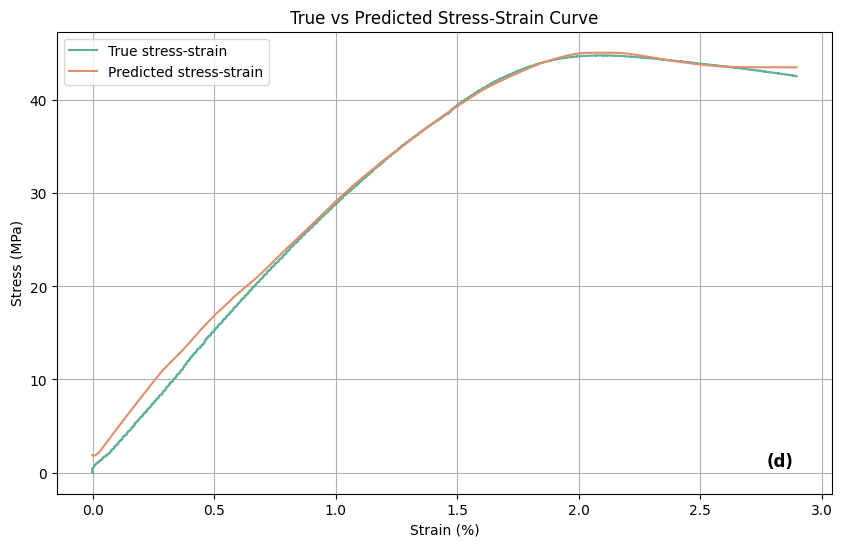

In [9]:
from tensorflow.keras.models import load_model, Model

# 确保保存图片的文件夹存在
folder_path = os.path.join('lstmtcn_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_in.transform(x_new)

# 创建新数据序列
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length + 1):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

sequence_length = 1  # 根据之前的模型设置
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载模型
model_path = os.path.join('TCNmodel', 'lstm_tcn_model.h5')
model = load_model(model_path)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值从三维转换为二维
y_pred_scaled_2d = y_pred_scaled.reshape(-1, y_pred_scaled.shape[-1])

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 过滤应变值小于或等于2.9的数据
mask = strain_truncated <= 2.9
strain_filtered = strain_truncated[mask]
stress_true_filtered = stress_true_truncated[mask]
stress_pred_filtered = stress_pred_truncated[mask]

# 绘制预测结果与真实值的对比图
plt.figure(figsize=(10, 6))
plt.plot(strain_filtered, stress_true_filtered, label='True stress-strain', color='#62B197')
plt.plot(strain_filtered, stress_pred_filtered, label='Predicted stress-strain', color='#E18E6D')
plt.xlabel('Strain (%)')
plt.ylabel('Stress (MPa)')
plt.legend()
plt.title('True vs Predicted Stress-Strain Curve')
plt.grid(True)
# 在右下角添加文本 (d)
plt.text(0.95, 0.05, '(d)', fontsize=12, fontweight='bold', ha='right', va='bottom', transform=plt.gca().transAxes)

# 保存图片
plt.savefig(os.path.join(folder_path, 'predicted_vs_true_stress_strain.png'))
plt.show()


79/79 [==============================] - 2s 4ms/step


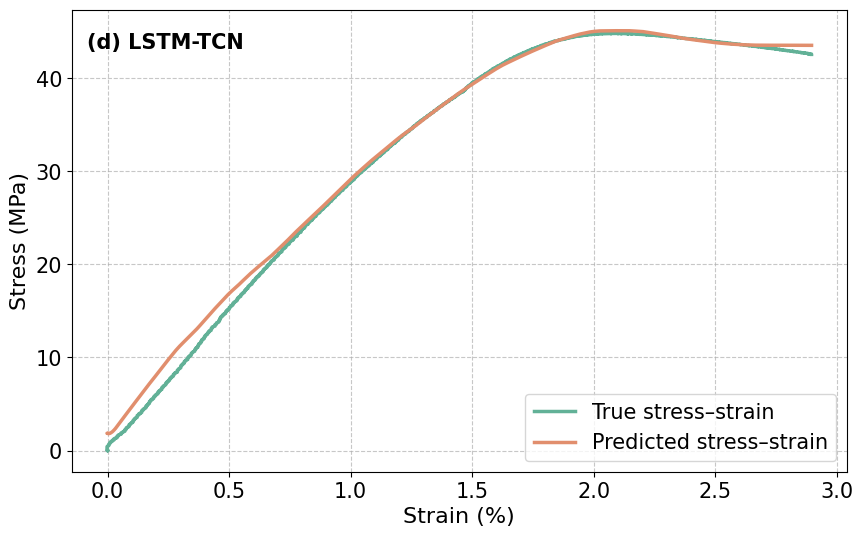

应力-应变曲线已保存并显示: lstmtcn_fig/prediction/predicted_vs_true_stress_strain.png


In [7]:
from tensorflow.keras.models import load_model, Model
# 确保保存图片的文件夹存在
folder_path = os.path.join('lstmtcn_fig', 'prediction')
os.makedirs(folder_path, exist_ok=True)

# 加载保存的scaler
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取新数据
file_name = 'Angle_group_5.csv'
df_new_data = pd.read_csv(file_name)

# 提取特征和真实值
strain = df_new_data.iloc[:, 1].values  # 假设第二列是应变值
stress_true = df_new_data.iloc[:, 2].values  # 第三列为真实应力值

# 对新数据进行归一化处理
x_new = df_new_data.iloc[:, :2].values  # 取前两列作为输入特征
x_new_scaled = scaler_in.transform(x_new)

# 创建新数据序列
def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length + 1):
        sequences.append(data[i:i + sequence_length])
    return np.array(sequences)

sequence_length = 1  # 根据之前的模型设置
x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载模型
model_path = os.path.join('TCNmodel', 'lstm_tcn_model.h5')
model = load_model(model_path)

# 进行预测
y_pred_scaled = model.predict(x_new_seq)

# 将预测值从三维转换为二维
y_pred_scaled_2d = y_pred_scaled.reshape(-1, y_pred_scaled.shape[-1])

# 将预测值逆归一化，恢复到原始尺度
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d).flatten()

# 确保预测值和实际值的长度相同
min_length = min(len(strain), len(stress_pred))
strain_truncated = strain[:min_length]
stress_true_truncated = stress_true[:min_length]
stress_pred_truncated = stress_pred[:min_length]

# 过滤应变值小于或等于2.9的数据（保持不变）
mask = strain_truncated <= 2.9
strain_filtered = strain_truncated[mask]
stress_true_filtered = stress_true_truncated[mask]
stress_pred_filtered = stress_pred_truncated[mask]

# —— 绘图（按统一样式；不改任何坐标范围与刻度设置） ——
plt.figure(figsize=(10, 6))
plt.plot(strain_filtered, stress_true_filtered,
         label='True stress–strain', color='#62B197', linewidth=2.5)
plt.plot(strain_filtered, stress_pred_filtered,
         label='Predicted stress–strain', color='#E18E6D', linewidth=2.5)

# 坐标轴与刻度字号
plt.xlabel('Strain (%)', fontsize=16)
plt.ylabel('Stress (MPa)', fontsize=16)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 图例与网格
plt.legend(fontsize=15, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# 左上角角标（模型名 + 面板序号）
plt.text(0.02, 0.95, '(d) LSTM-TCN', transform=plt.gca().transAxes,
         fontsize=15, fontweight='bold', ha='left', va='top')

# 保存图片（路径不变）
save_path = os.path.join(folder_path, 'predicted_vs_true_stress_strain.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

# 显示并关闭
plt.show()
plt.close()

print(f"应力-应变曲线已保存并显示: {save_path}")


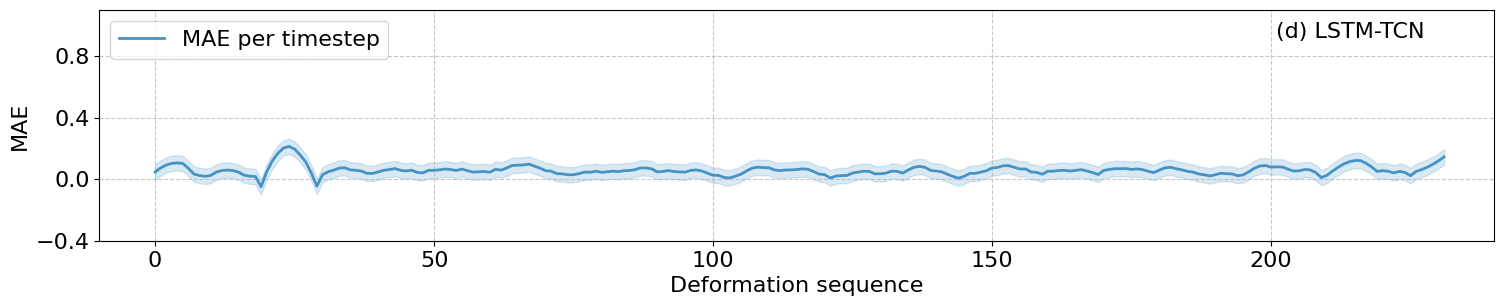

MAE per timestep plot saved and displayed: ./lstmtcn_fig/mae_per_timestep.png


In [5]:
from scipy.signal import savgol_filter
from matplotlib.ticker import MultipleLocator

# 假设 y_test_seq 和 y_pred 是你的测试数据和预测结果
# 这里我们使用 y_val 和 predictions 作为示例
y_test_seq = y_val.reshape(-1, 1)  # 确保 y_test_seq 是二维的
y_pred = predictions.reshape(-1, 1)  # 确保 y_pred 是二维的

# 计算每个时间步的 MAE
mae_per_timestep = np.abs(y_test_seq - y_pred).mean(axis=1)

# 采样数据以减少密度（例如，每隔90个点取一个）
sampling_rate = 90
mae_sampled = mae_per_timestep[::sampling_rate]

# 确保 window_length 小于或等于数据长度，并且是奇数
window_length = min(11, len(mae_sampled))
if window_length % 2 == 0:
    window_length -= 1

# 如果 window_length 仍然大于数据长度，调整为数据长度的最大奇数
if window_length < 3:
    window_length = 3

# 平滑曲线（使用 Savitzky-Golay 滤波器）
polyorder = 2  # 确保 polyorder 小于 window_length
mae_smoothed = savgol_filter(mae_sampled, window_length, polyorder)


# 绘制 MAE 随时间变化的图
plt.figure(figsize=(18, 3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(mae_smoothed, label='MAE per timestep', color='#4493C4', linewidth=2)

# 添加跟随曲线变化的窄色条
offset = 0.05  # 设置窄色条的宽度
plt.fill_between(range(len(mae_smoothed)), mae_smoothed - offset, mae_smoothed + offset, color='#4493C4', alpha=0.2)

# 设置图例位置为左上角
plt.legend(loc='upper left', fontsize=16)

# 在右上角添加文本
plt.text(0.95, 0.95, '(d) LSTM-TCN', fontsize=16,  ha='right', va='top', transform=plt.gca().transAxes)

plt.xlabel('Deformation sequence', fontsize=16)
plt.ylabel('MAE', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(-0.4, 1.1)
plt.xlim(-10, 240)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.4))

# 保存图像
mae_timestep_path = './lstmtcn_fig/mae_per_timestep.png'
plt.savefig(mae_timestep_path, dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

# 关闭当前图形以释放内存
plt.close()

print(f"MAE per timestep plot saved and displayed: {mae_timestep_path}")


Normalization scalers have been re-created.
LSTM-TCN model successfully loaded from './TCNmodel/lstm_tcn_model.h5'.


2025-09-10 19:41:20.648004: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600


3259/3259 [==============================] - 10s 3ms/step
Error calculation for the LSTM-TCN model on the full dataset is complete.


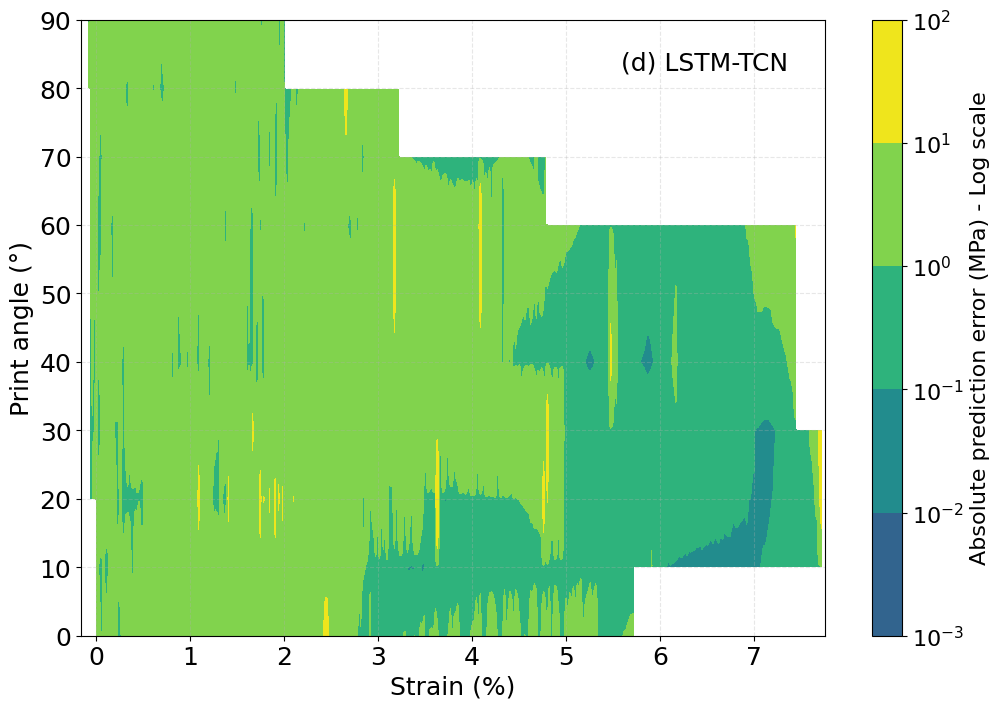


LSTM-TCN model's error contour plot has been saved to: ./lstmtcn_fig/lstmtcn_error_contour_log_scale_formatted.png


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tensorflow.keras.models import load_model
import os

# --- Step 1: Load full dataset and re-create scalers ---
data = pd.read_csv("data.csv")
# Correct column order: Column 0 is Angle, Column 1 is Strain
inputs_full = data.iloc[:, :2].values
output_full_true = data.iloc[:, 2].values.reshape(-1, 1)

# Re-create and fit scalers to solve any file path issues
scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()
inputs_full_scaled = scaler_in.fit_transform(inputs_full)
scaler_out.fit(output_full_true)
print("Normalization scalers have been re-created.")

# --- Step 2: Load the complete Keras model from the correct path ---
# **CRITICAL CORRECTION**: Using the correct model path from your notebook
model_path = './TCNmodel/lstm_tcn_model.h5'
try:
    model_lstmtcn = load_model(model_path)
    print(f"LSTM-TCN model successfully loaded from '{model_path}'.")
except Exception as e:
    print(f"ERROR: Could not load the model ({e}).")
    print(f"Please ensure the file path '{model_path}' is correct relative to your notebook's location.")
    exit()

# --- Step 3: Predict on the full dataset with the CORRECT sequence length ---
# **CRITICAL CORRECTION**: Using sequence_length = 1 as defined in your notebook
sequence_length = 1

def create_sequences(data, seq_length):
    sequences = []
    # This loop structure works for sequence_length = 1
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_full_seq = create_sequences(inputs_full_scaled, sequence_length)
y_full_pred_scaled = model_lstmtcn.predict(x_full_seq)

# The model output shape should be (num_samples, 1, 1), so we reshape for inverse transform
y_full_pred_scaled_reshaped = y_full_pred_scaled.reshape(-1, 1)
y_full_pred_original = scaler_out.inverse_transform(y_full_pred_scaled_reshaped)

# Align the true values with the predictions
y_full_true_aligned = output_full_true[sequence_length - 1:]
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_aligned.flatten())

# Align the feature data for plotting
strain = inputs_full[sequence_length - 1:, 1]  # Column 1 is Strain
angle = inputs_full[sequence_length - 1:, 0]   # Column 0 is Angle

df_plot = pd.DataFrame({'Strain': strain, 'Angle': angle, 'Error': absolute_error})
print("Error calculation for the LSTM-TCN model on the full dataset is complete.")

# --- Step 4: Use step-wise interpolation and log scale plotting ---
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())
grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)
aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        interp_func = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = interp_func(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i, s in enumerate(strain_common):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    valid_indices = ~np.isnan(current_errors)
    if np.sum(valid_indices) > 1:
        interp_func_angle = interp1d(
            np.array(valid_angles)[valid_indices],
            np.array(current_errors)[valid_indices],
            bounds_error=False, fill_value=np.nan
        )
        final_grid_error[:, i] = interp_func_angle(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

# Plot the final chart
target_strain, target_angle = np.meshgrid(strain_common, angle_grid_dense)
plt.style.use('default')
fig, ax = plt.subplots(figsize=(12, 8))
final_grid_error_masked = np.ma.masked_invalid(final_grid_error)
min_error_for_log = df_plot['Error'][df_plot['Error'] > 0].min()
norm = mcolors.LogNorm(vmin=min_error_for_log, vmax=df_plot['Error'].max())
contour = ax.contourf(target_strain, target_angle, final_grid_error_masked, levels=100, cmap='viridis', norm=norm)

# Format the chart
cbar = fig.colorbar(contour)
cbar.set_label('Absolute prediction error (MPa) - Log scale', fontsize=16)
cbar.ax.tick_params(labelsize=16)
ax.set_xlabel('Strain (%)', fontsize=18)
ax.set_ylabel('Print angle (°)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.3)
ax.tick_params(axis='both', which='major', labelsize=18)

# Add subplot label (not bold)
ax.text(0.95, 0.95, '(d) LSTM-TCN',
        transform=ax.transAxes,
        fontsize=18,
        fontweight='normal',
        ha='right',
        va='top')

# Save the image
final_plot_path = './lstmtcn_fig/lstmtcn_error_contour_log_scale_formatted.png'
os.makedirs(os.path.dirname(final_plot_path), exist_ok=True)
plt.savefig(final_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"\nLSTM-TCN model's error contour plot has been saved to: {final_plot_path}")

In [5]:
# 计算并保存 df_plot 与重采样网格（noTL_docs/lstmtcn）——最小改动，不改绘图
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from scipy.interpolate import interp1d
from tensorflow.keras.models import load_model

# 1) 在全数据上生成 df_plot（沿用本笔记本一致做法：重建并拟合 MinMaxScaler）
data_full = pd.read_csv('data.csv')
data_full.drop_duplicates(inplace=True)

# 列顺序：Angle, Strain, Stress
inputs_full = data_full.iloc[:, :2].values
output_full_true = data_full.iloc[:, 2].values.reshape(-1, 1)

scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()
inputs_full_scaled = scaler_in.fit_transform(inputs_full)
scaler_out.fit(output_full_true)

# 加载完整模型（路径与本笔记本一致）
model_path = './TCNmodel/lstm_tcn_model.h5'
model_lstmtcn = load_model(model_path)

# 序列长度（与本笔记本保持一致）
sequence_length = 1

def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

x_full_seq = create_sequences(inputs_full_scaled, sequence_length)

# 预测并反归一化
y_full_pred_scaled = model_lstmtcn.predict(x_full_seq)
y_full_pred_scaled_reshaped = y_full_pred_scaled.reshape(-1, 1)
y_full_pred_original = scaler_out.inverse_transform(y_full_pred_scaled_reshaped)

# 对齐真实值与特征（序列预测对齐到第 seq_length-1 个样本）
y_full_true_aligned = output_full_true[sequence_length - 1:]
absolute_error = np.abs(y_full_pred_original.flatten() - y_full_true_aligned.flatten())
strain = inputs_full[sequence_length - 1:, 1]
angle = inputs_full[sequence_length - 1:, 0]

# 保存 df_plot
df_plot = pd.DataFrame({'Strain': strain, 'Angle': angle, 'Error': absolute_error})
out_dir = './noTL_docs/lstmtcn'
os.makedirs(out_dir, exist_ok=True)
df_plot.to_csv(os.path.join(out_dir, 'df_plot.csv'), index=False)

# 2) 生成重采样网格并保存
df_plot['Angle_Group'] = df_plot['Angle'].round(0)
unique_angles = sorted(df_plot['Angle_Group'].unique())

grid_resolution = 400
strain_common = np.linspace(df_plot['Strain'].min(), df_plot['Strain'].max(), grid_resolution)
angle_grid_dense = np.linspace(df_plot['Angle'].min(), df_plot['Angle'].max(), grid_resolution)

aligned_errors = {}
for ang in unique_angles:
    group = df_plot[df_plot['Angle_Group'] == ang].sort_values('Strain')
    if len(group) > 1:
        f = interp1d(group['Strain'], group['Error'], bounds_error=False, fill_value=np.nan)
        aligned_errors[ang] = f(strain_common)

final_grid_error = np.zeros((len(angle_grid_dense), len(strain_common)))
for i in range(len(strain_common)):
    current_errors = [aligned_errors[ang][i] for ang in unique_angles if ang in aligned_errors]
    valid_angles = [ang for ang in unique_angles if ang in aligned_errors]
    current_errors = np.array(current_errors)
    valid_angles = np.array(valid_angles)
    valid_mask = ~np.isnan(current_errors)
    if np.sum(valid_mask) > 1:
        g = interp1d(valid_angles[valid_mask], current_errors[valid_mask], bounds_error=False, fill_value=np.nan)
        final_grid_error[:, i] = g(angle_grid_dense)
    else:
        final_grid_error[:, i] = np.nan

np.save(os.path.join(out_dir, 'strain_common.npy'), strain_common)
np.save(os.path.join(out_dir, 'angle_grid_dense.npy'), angle_grid_dense)
np.save(os.path.join(out_dir, 'final_grid_error.npy'), final_grid_error)
np.savez(os.path.join(out_dir, 'lstmtcn_grids.npz'),
         strain_common=strain_common,
         angle_grid_dense=angle_grid_dense,
         final_grid_error=final_grid_error)

print(f"LSTM-TCN df_plot 与网格已保存至: {out_dir}")


3237/3237 [==============================] - 9s 2ms/step
LSTM-TCN df_plot 与网格已保存至: ./noTL_docs/lstmtcn


In [5]:
# 计算 Angle_group_5.csv 的 MAE / RMSE / R²（全量与 Strain≤2.9）并保存
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import load_model

# 输出目录
out_dir = os.path.join('lstmtcn_fig', 'prediction')
os.makedirs(out_dir, exist_ok=True)

# 加载 scaler（与本笔记本一致：MinMaxScaler）
scaler_in = joblib.load('scalers/scaler_in.pkl')
scaler_out = joblib.load('scalers/scaler_out.pkl')

# 读取未见测试集
file_name = 'Angle_group_5.csv'
df_new = pd.read_csv(file_name)

# 特征与真实值（列顺序：Angle, Strain, Stress）
x_new = df_new.iloc[:, :2].values
strain = df_new.iloc[:, 1].values  # 第二列应变
stress_true = df_new.iloc[:, 2].values.reshape(-1, 1)  # 第三列真实应力

# 归一化与序列构造（sequence_length=1 与笔记本保持一致）
sequence_length = 1
x_new_scaled = scaler_in.transform(x_new)

def create_sequences(data, seq_length):
    seqs = []
    for i in range(len(data) - seq_length + 1):
        seqs.append(data[i:i + seq_length])
    return np.array(seqs)

x_new_seq = create_sequences(x_new_scaled, sequence_length)

# 加载完整模型并预测
model_path = os.path.join('TCNmodel', 'lstm_tcn_model.h5')
model_lstmtcn = load_model(model_path)

y_pred_scaled = model_lstmtcn.predict(x_new_seq)
# (N, 1, 1) -> (N, 1)
y_pred_scaled_2d = y_pred_scaled.reshape(-1, 1)
# 反归一化到原始量纲
stress_pred = scaler_out.inverse_transform(y_pred_scaled_2d)

# 对齐长度并扁平化
min_len = min(len(stress_true), len(stress_pred))
true_all = stress_true[:min_len].flatten()
pred_all = stress_pred[:min_len].flatten()
strain_all = strain[:min_len]

# 全量指标
mse_all = mean_squared_error(true_all, pred_all)
rmse_all = np.sqrt(mse_all)
mae_all = mean_absolute_error(true_all, pred_all)
r2_all = r2_score(true_all, pred_all)

# 阈值内（与绘图一致）：Strain ≤ 2.9
mask = strain_all <= 2.9
true_thr = true_all[mask]
pred_thr = pred_all[mask]

mse_thr = mean_squared_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
rmse_thr = np.sqrt(mse_thr) if np.isfinite(mse_thr) else np.nan
mae_thr = mean_absolute_error(true_thr, pred_thr) if len(true_thr) > 0 else np.nan
r2_thr = r2_score(true_thr, pred_thr) if len(true_thr) > 1 else np.nan

# 打印结果
print('=== Angle_group_5.csv metrics (LSTM-TCN) ===')
print(f'All samples   -> MAE={mae_all:.4f}, RMSE={rmse_all:.4f}, R²={r2_all:.4f}')
if np.isfinite(mae_thr):
    print(f'Strain≤2.9   -> MAE={mae_thr:.4f}, RMSE={rmse_thr:.4f}, R²={r2_thr:.4f}')
else:
    print('Strain≤2.9   -> 无有效样本')

# 保存 CSV
metrics_df = pd.DataFrame([
    {'scope': 'all',        'MAE': mae_all, 'RMSE': rmse_all, 'R2': r2_all},
    {'scope': 'strain<=2.9','MAE': mae_thr, 'RMSE': rmse_thr, 'R2': r2_thr},
])
metrics_path = os.path.join(out_dir, 'Angle_group_5_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved to: {metrics_path}')


79/79 [==============================] - 1s 4ms/step
=== Angle_group_5.csv metrics (LSTM-TCN) ===
All samples   -> MAE=0.7901, RMSE=2.0264, R²=0.9786
Strain≤2.9   -> MAE=0.5995, RMSE=0.9214, R²=0.9957
Metrics saved to: lstmtcn_fig/prediction/Angle_group_5_metrics.csv


In [5]:
# 导出 LSTM-TCN 残差CSV（pred-true），默认仅 Strain≤2.5
import os, numpy as np, pandas as pd, joblib
from tensorflow.keras.models import load_model

STRAIN_MAX = 2.5  # 设为 None 则导出全量
SEQLEN = 1        # 该模型用 1 步

# 读取测试集
df = pd.read_csv('Angle_group_5.csv')
x_new = df.iloc[:, :2].values
strain = df.iloc[:, 1].values
stress_true = df.iloc[:, 2].values

# 加载 MinMaxScaler
try:
    _ = scaler_in.min_; _ = scaler_out.min_
except Exception:
    scaler_in  = joblib.load('scalers/scaler_in.pkl')
    scaler_out = joblib.load('scalers/scaler_out.pkl')

# 加载模型
model = load_model('TCNmodel/lstm_tcn_model.h5')

# 构造序列并预测
def make_seq(a, L):
    return np.array([a[i:i+L] for i in range(len(a)-L+1)])
x_scaled = scaler_in.transform(x_new)
x_seq = make_seq(x_scaled, SEQLEN)
y_pred_scaled = model.predict(x_seq, verbose=0)
if y_pred_scaled.ndim == 3:
    y_pred_scaled = y_pred_scaled.reshape(-1, 1)
y_pred = scaler_out.inverse_transform(y_pred_scaled).flatten()

# 对齐与残差
n = min(len(strain), len(y_pred), len(stress_true))
strain = strain[:n]
residual = y_pred[:n] - stress_true[:n]

# 筛选
if STRAIN_MAX is not None:
    mask = strain <= STRAIN_MAX
    strain, residual = strain[mask], residual[mask]

# 保存
out_dir = 'lstmtcn_fig/prediction'; os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'residuals_LSTMTCN.csv')
pd.DataFrame({'strain': strain, 'residual': residual}).to_csv(out_path, index=False)
print('saved:', out_path)

saved: lstmtcn_fig/prediction/residuals_LSTMTCN.csv
